# Regularization

When we explored Multiple Linear Regression, we tried to select features by inspecting correlations between a feature and the target as well as between features. But how did we know if we were using the right features and the right number of features? We didn't.

*Regularization* is a tool for automatically emphasizing the features that are informative as you fit the model. Recall, in fitting linear regression models, we are minimizing the mean-squared error between our predictions and the true values. The cost function has the form:

$$
J(\Theta) = \frac{1}{m}\sum_{i=0}^m(y_i - \hat{y}_i)^2
$$

Regularization adds a term to the cost function that penalizes large feature weights ($\theta_i$). Three common regularization algorithms for linear regression are:

 - [Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html):

 $$
J_{\text{ridge}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + \frac{\alpha}{n} \cdot \underbrace{\sum_{i=0}^p \theta_i^2}_{\text{L2 norm}}
$$

 - [Lasso regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) (Least Absolute Shrinkage and Selection Operator):

 $$
J_{\text{lasso}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + 2\alpha \cdot \underbrace{\sum_{i=0}^p |\theta_i|}_{\text{L1 norm}}
$$

- [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) (combines Ridge and Lasso)

 $$
J_{\text{elastic net}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + r\cdot\underbrace{\frac{\alpha}{n} \cdot \frac{1}{2}\sum_{i=0}^p \theta_i^2}_{\text{Ridge}} + (1-r)\underbrace{\cdot2\alpha \cdot \sum_{i=0}^p |\theta_i|}_{\text{Lasso}}
$$

Where 
 - $\alpha$ is a hyper-parameter that balances how much you want to balance model simplification and model fit.
 - L2 norm is the sum of squared values of weights
 - L1 norm is the sum of the absolute values of weights
 - $r$ is a hyper-parameter in the range (0,1) that balances the amount of L2 (Ridge) and L1 (Lasso) penalty

That Ridge uses the L2-norm and Lasso uses the L1-norm can be reduced to the following observation:
 - Ridge regression will make some weights small, but not zero. This is useful if you believe many of the features contribute to the model.
 - Lasso regression will drive some weights to zero. This is useful if you believe only a few weights contribute.

 However, we generally don't know in advance how our features will contribute to the model, so best to try both and compare.


 ### Why/when to use regularization?

 - *High-dimensional data.* When number of features (p) is larger than the number of samples (n), linear regression (Ordinary Least Squares) fails.
 - *Colinear features.* Linear regression yields unstable coefficient estimates because multiple best-fit solutions exist.
 - *Model over-fitting.* Even when p<n, you may have too many parameters. That is, you're using a model more complex than the data requires. (More about that next class!)
 - *Feature selection.* You want to build a model with fewer features.

### Example: Baseball Salary Prediction (1986)

In [1]:
import pandas as pd
pd.set_option('display.precision', 2)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis and Cleaning

In [4]:
data_df = pd.read_csv('https://raw.githubusercontent.com/acakin/hitters/refs/heads/master/hitters.csv')      
data_df = data_df.dropna()

data_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [6]:
## One-hot Encoding

cat_features = ['League', 'Division', 'NewLeague']

league_df = pd.get_dummies(data_df[cat_features], dtype = int)
#league_df

In [9]:
data_df2 = data_df.drop(columns = cat_features)
hitters_df = league_df.join(data_df2)
#hitters_df

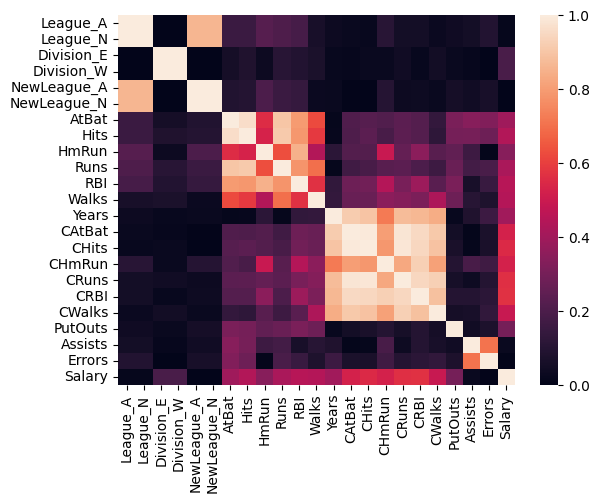

In [10]:
hitters_corr = hitters_df.corr()

sns.heatmap(np.abs(hitters_corr), vmin =0, vmax = 1)
plt.show()

## Modeling

In [11]:
target = 'Salary'

y = hitters_df[target]
X = hitters_df.drop(columns = target)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

sc = StandardScaler()
sc.fit(X_train)

Z_train = sc.transform(X_train)
Z_test = sc.transform(X_test)

In [15]:
# Create and Fit the model
linreg = LinearRegression()
linreg.fit(Z_train, y_train)

# Make predictions

y_linreg_train = linreg.predict(Z_train)
y_linreg_test = linreg.predict(Z_test)

In [16]:
linreg.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 22,
 'coef_': array([ -18.96221584,   18.96221584,   21.78916012,  -21.78916012,
           2.26996471,   -2.26996471,  -99.02623274,  176.45052631,
         125.4986177 ,  -65.2064475 ,  -97.73200425,  106.0759255 ,
          91.82709428, -528.21689098,  -17.74583951, -169.22768239,
         591.42295782,  379.600882  , -210.28111648,   65.74335499,
          42.28915088,  -37.15906899]),
 'rank_': 19,
 'singular_': array([3.94152937e+01, 3.00847151e+01, 2.68756452e+01, 2.04676380e+01,
        1.88166345e+01, 1.37520495e+01, 1.17241634e+01, 1.07173806e+01,
        7.61680017e+00, 7.24194566e+00, 5.85613097e+00, 5.42243767e+00,
        4.15782579e+00, 3.61625088e+00, 3.27876200e+00, 2.29516468e+00,
        1.67706918e+00, 1.01339483e+00, 4.86090075e-01, 3.77984605e-15,
        1.18188328e-15, 8.38924426e-16]),
 'intercept_': np.float64(514.675280952381)}

In [17]:
feature_names = list(X.columns)

for f, c in zip(feature_names, linreg.coef_):
    print(f'{f}:\t\t{c:0.2f}')

League_A:		-18.96
League_N:		18.96
Division_E:		21.79
Division_W:		-21.79
NewLeague_A:		2.27
NewLeague_N:		-2.27
AtBat:		-99.03
Hits:		176.45
HmRun:		125.50
Runs:		-65.21
RBI:		-97.73
Walks:		106.08
Years:		91.83
CAtBat:		-528.22
CHits:		-17.75
CHmRun:		-169.23
CRuns:		591.42
CRBI:		379.60
CWalks:		-210.28
PutOuts:		65.74
Assists:		42.29
Errors:		-37.16


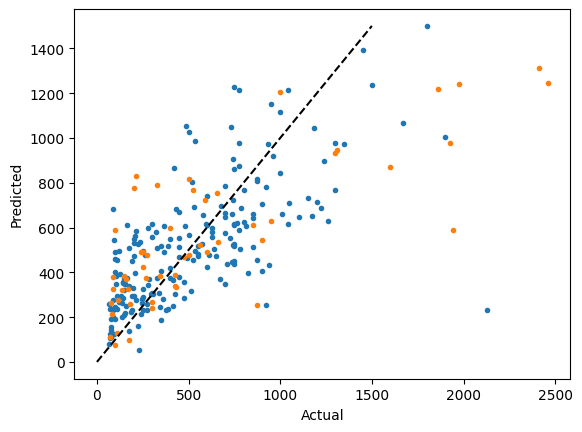

In [19]:
plt.plot(y_train, y_linreg_train, '.')
plt.plot(y_test, y_linreg_test, '.')

plt.plot([0, 1500], [0, 1500], 'k--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [28]:
a = 3

# Create the model and choose the hyperparameter
lasso = Lasso(alpha = a)
lasso.fit(Z_train, y_train)

# Make predictions
y_lasso_train = lasso.predict(Z_train)
y_lasso_test = lasso.predict(Z_test)

print(f'ALPHA = {a}')
for f, c in zip(feature_names, lasso.coef_):
    print(f'{f}:\t\t{c:0.2f}')



ALPHA = 3
League_A:		-30.37
League_N:		0.00
Division_E:		41.98
Division_W:		-0.00
NewLeague_A:		-0.00
NewLeague_N:		0.00
AtBat:		-22.61
Hits:		53.90
HmRun:		35.81
Runs:		0.00
RBI:		-0.00
Walks:		65.48
Years:		8.74
CAtBat:		-0.00
CHits:		0.00
CHmRun:		-0.00
CRuns:		231.24
CRBI:		31.28
CWalks:		-113.69
PutOuts:		60.45
Assists:		8.99
Errors:		-30.78


In [32]:
alpha = np.logspace(-2,3,11)

lasso_coefs = {}
lasso_coefs['features'] = feature_names

for a in alpha:
# Create the model and choose the hyperparameter
    lasso = Lasso(alpha = a)
    lasso.fit(Z_train, y_train)

    # Make predictions
    y_lasso_train = lasso.predict(Z_train)
    y_lasso_test = lasso.predict(Z_test)
    
    lasso_coefs[a] = lasso.coef_
    
lasso_df = pd.DataFrame(lasso_coefs)
lasso_df.sort_values(by=100, ascending = False)

/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.543e+06, tolerance: 3.170e+03
  model = cd_fast.enet_coordinate_descent(
/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.542e+06, tolerance: 3.170e+03
  model = cd_fast.enet_coordinate_descent(
/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

,features,0.01,0.03,0.1,0.32,1.0,3.16,10.0,31.62,100.0,316.23,1000.0
16,CRuns,5.71e+02,5.68e+02,5.60e+02,5.34e+02,4.08e+02,2.27e+02,1.22e+02,1.28e+02,98.70,0.0,0.0
10,RBI,-9.65e+01,-9.55e+01,-9.23e+01,-8.24e+01,-4.96e+01,-0.00e+00,0.00e+00,0.00e+00,16.51,0.0,0.0
7,Hits,1.69e+02,1.68e+02,1.66e+02,1.59e+02,1.25e+02,4.86e+01,5.42e+01,4.24e+01,7.59,0.0,0.0
11,Walks,1.04e+02,1.04e+02,1.03e+02,1.00e+02,8.95e+01,6.33e+01,3.28e+01,2.74e+01,7.32,0.0,0.0
17,CRBI,3.63e+02,3.60e+02,3.50e+02,3.17e+02,1.86e+02,3.04e+01,1.50e+01,2.44e+01,2.12,0.0,0.0
12,Years,9.47e+01,9.38e+01,9.08e+01,8.13e+01,5.27e+01,8.65e+00,0.00e+00,0.00e+00,0.00,0.0,0.0
20,Assists,4.29e+01,4.26e+01,4.17e+01,3.89e+01,3.06e+01,7.50e+00,-0.00e+00,-0.00e+00,-0.00,-0.0,-0.0
19,PutOuts,6.57e+01,6.57e+01,6.57e+01,6.56e+01,6.52e+01,6.01e+01,5.56e+01,4.25e+01,0.00,0.0,0.0
18,CWalks,-2.04e+02,-2.03e+02,-2.02e+02,-1.99e+02,-1.79e+02,-1.08e+02,-0.00e+00,0.00e+00,0.00,0.0,0.0
15,CHmRun,-1.58e+02,-1.56e+02,-1.51e+02,-1.36e+02,-6.70e+01,-0.00e+00,0.00e+00,0.00e+00,0.00,0.0,0.0


In [33]:
alpha = np.logspace(-2,3,11)

ridge_coefs = {}
ridge_coefs['features'] = feature_names

for a in alpha:
# Create the model and choose the hyperparameter
    ridge = Ridge(alpha = a)
    ridge.fit(Z_train, y_train)

    # Make predictions
    y_ridge_train = ridge.predict(Z_train)
    y_ridge_test = ridge.predict(Z_test)
    
    ridge_coefs[a] = ridge.coef_
    
ridge_df = pd.DataFrame(ridge_coefs)
ridge_df.sort_values(by=100, ascending = False)

,features,0.01,0.03,0.1,0.32,1.0,3.16,10.0,31.62,100.0,316.23,1000.0
19,PutOuts,65.74,65.75,65.75,65.73,65.40,64.18,6.15e+01,55.72,44.14,28.07,14.16
16,CRuns,585.57,573.67,541.16,467.38,342.71,204.74,1.08e+02,59.53,37.70,26.73,17.94
14,CHits,-12.94,-3.76,17.63,50.81,78.68,85.71,7.19e+01,51.04,35.70,26.00,17.53
17,CRBI,374.57,364.32,336.27,273.64,177.92,96.31,5.50e+01,36.15,27.92,23.13,16.82
11,Walks,105.88,105.49,104.45,101.91,95.60,81.22,5.91e+01,39.08,27.87,21.12,14.01
7,Hits,175.68,174.16,170.21,161.40,142.07,104.39,6.15e+01,36.91,26.91,20.42,13.50
9,Runs,-64.27,-62.36,-57.15,-45.17,-23.49,4.13,2.42e+01,28.89,25.31,19.94,13.36
13,CAtBat,-524.90,-517.43,-492.64,-419.16,-271.66,-110.42,-1.56e+01,17.14,23.51,21.75,16.10
12,Years,91.24,89.97,86.10,75.68,55.92,35.10,2.46e+01,21.97,20.73,18.35,13.68
8,HmRun,124.82,123.41,119.47,110.06,93.14,71.59,4.95e+01,30.82,20.28,16.02,11.66
